Analyzing training results from: run_20250328_182333

## Confusion Matrix


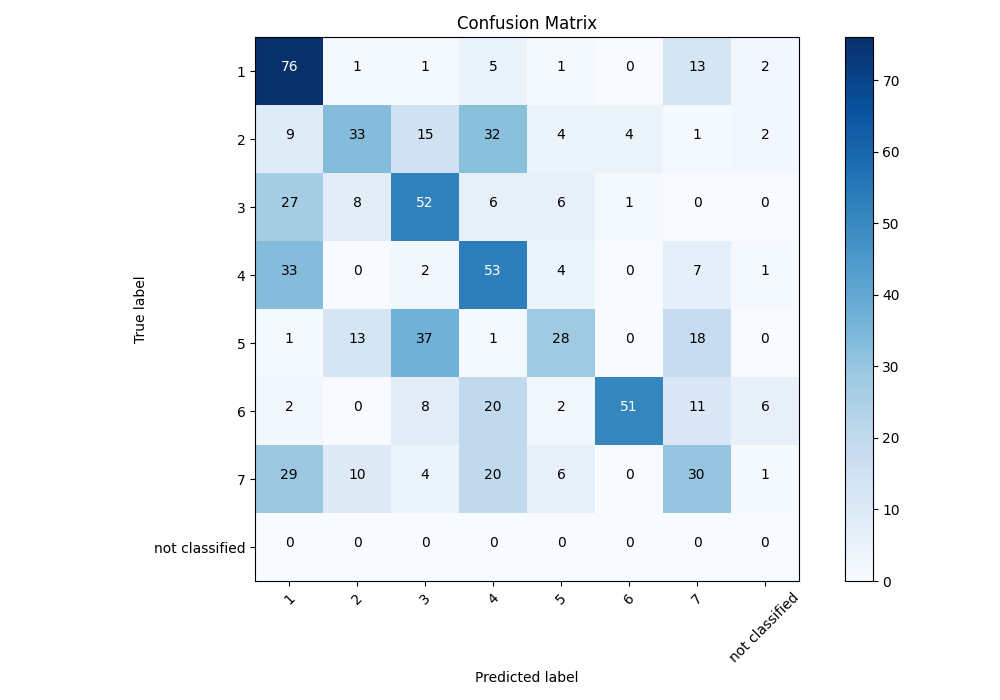


## Per-Class Performance Metrics


/var/folders/zt/639dblsn43v4cm44n5q06qwh0000gp/T/ipykernel_39909/3237168175.py:52: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/var/folders/zt/639dblsn43v4cm44n5q06qwh0000gp/T/ipykernel_39909/3237168175.py:52: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/var/folders/zt/639dblsn43v4cm44n5q06qwh0000gp/T/ipykernel_39909/3237168175.py:52: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/var/folders/zt/639dblsn43v4cm44n5q06qwh0000gp/T/ipykernel_39909/3237168175.py:52: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, 

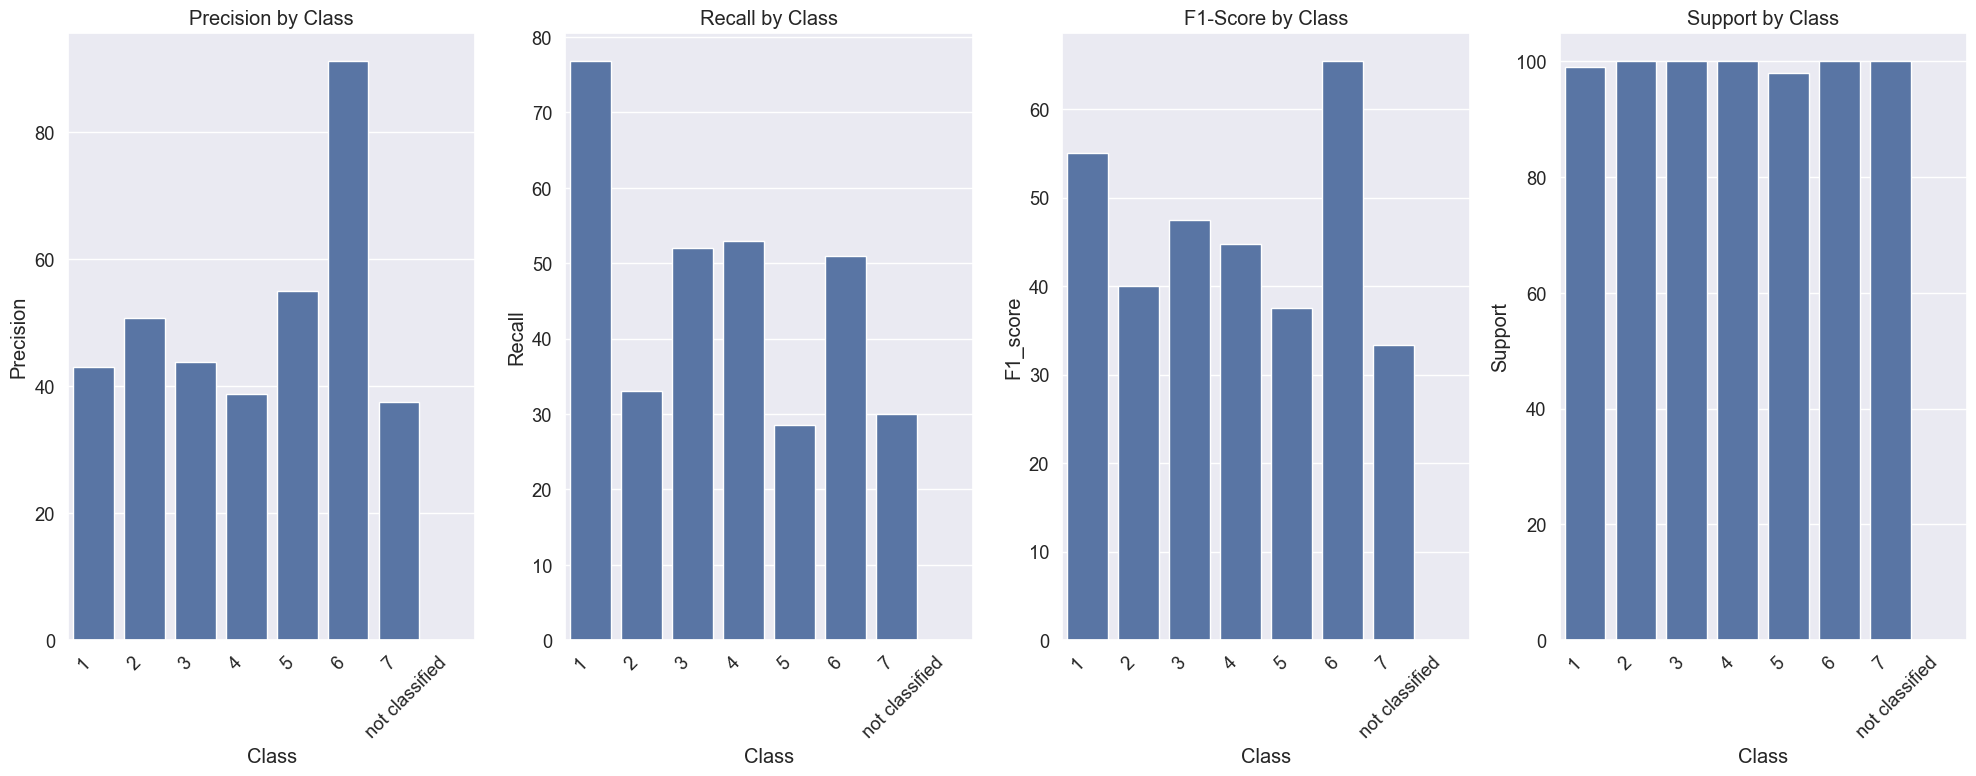

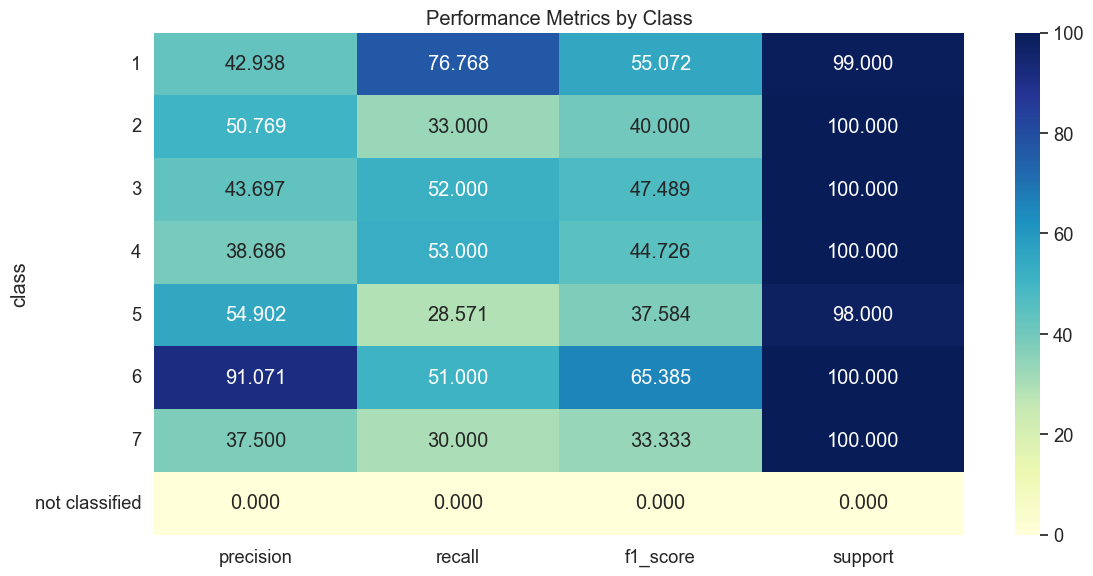


## Overall Performance Metrics


,Metric,Value
0,Total Images,700.000000
1,Failed (DLQ),3.000000
2,Successfully Classified,697.000000
3,Success Rate (%),100.000000
4,Accuracy (%),46.341463
5,Precision (%),51.368245
6,Recall (%),46.341463
7,F1 Score (%),46.239057


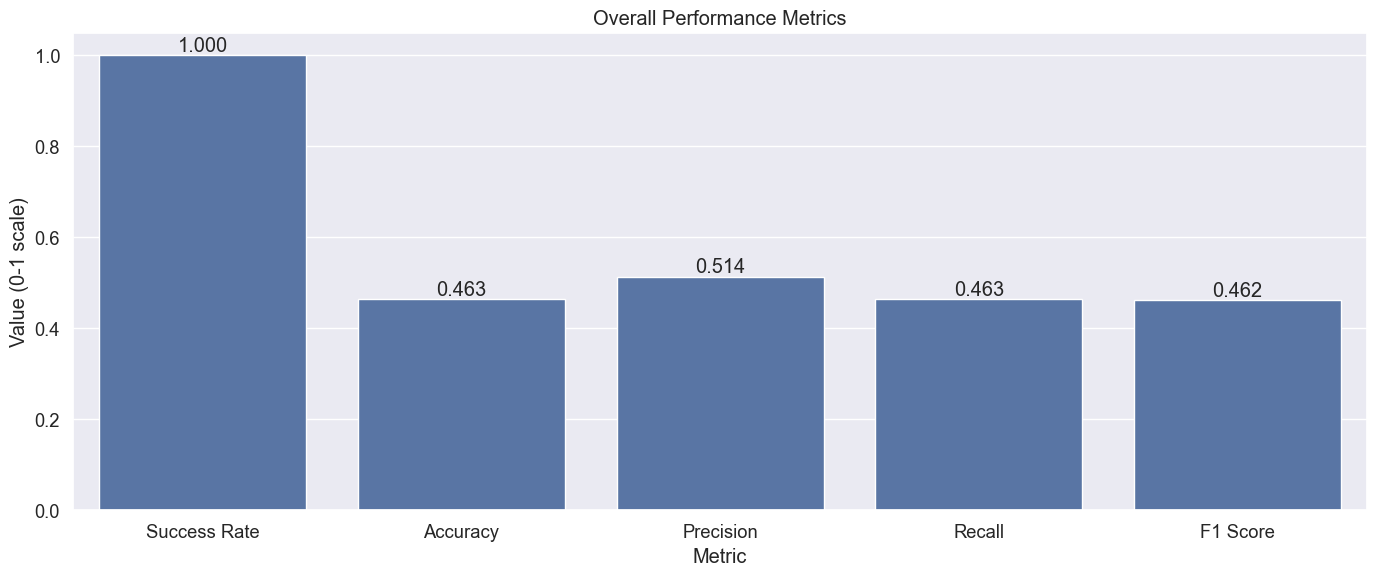


## Analysis of Incorrect Predictions
Top 20 Most Common Misclassifications:


,Expected Label,Predicted Label,Count
23,5,3,37
17,4,1,33
8,2,4,32
32,7,1,29
12,3,1,27
35,7,4,20
29,6,4,20
25,5,7,18
7,2,3,15
4,1,7,13


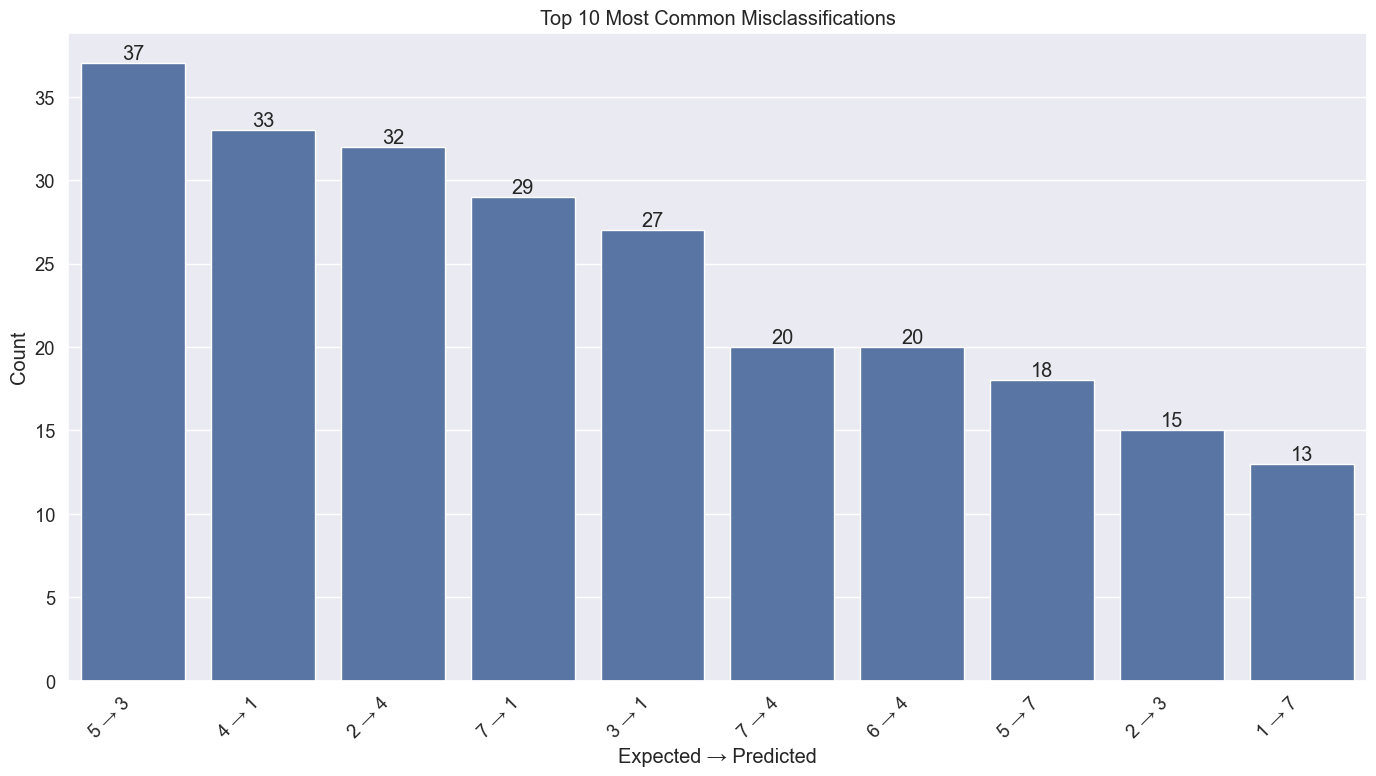


Number of 'not classified' instances: 12 (3.18%)

Distribution of 'not classified' instances by expected label:


,Expected Label,Count
3,6,6
0,1,2
1,2,2
2,4,1
4,7,1



Visualization complete!


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np
from IPython.display import Image, display

# Set plot style for better visualizations
plt.style.use('ggplot')
sns.set(font_scale=1.2)
plt.rcParams['figure.figsize'] = [12, 8]

# Function to find the latest training run folder
def get_latest_run_folder(base_path):
    training_results_path = os.path.join(base_path, 'src', 'training', 'training_results')
    run_folders = [f for f in os.listdir(training_results_path) if f.startswith('run_')]
    if not run_folders:
        raise FileNotFoundError("No training run folders found")
    return os.path.join(training_results_path, sorted(run_folders)[-1])

# Read from a specific folder or find the latest
# training_folder = '/Users/mlapin/Development/personal/NaturalAGI/src/training/training_results/run_20250325_205109'
training_folder = get_latest_run_folder('/Users/mlapin/Development/personal/NaturalAGI')

print(f"Analyzing training results from: {os.path.basename(training_folder)}")

# 1. Display the confusion matrix image
confusion_matrix_path = os.path.join(training_folder, 'confusion_matrix.png')
if os.path.exists(confusion_matrix_path):
    print("\n## Confusion Matrix")
    display(Image(filename=confusion_matrix_path))
else:
    print("Confusion matrix image not found")

# 2. Visualize per-class metrics
per_class_path = os.path.join(training_folder, 'per_class_metrics.csv')
if os.path.exists(per_class_path):
    print("\n## Per-Class Performance Metrics")
    per_class_df = pd.read_csv(per_class_path)
    
    # Create a figure with subplots for precision, recall, and F1-score
    fig, axs = plt.subplots(1, 4, figsize=(20, 8))
    metrics = ['precision', 'recall', 'f1_score', 'support']
    titles = ['Precision by Class', 'Recall by Class', 'F1-Score by Class', 'Support by Class']
    
    for i, (metric, title) in enumerate(zip(metrics, titles)):
        if metric in per_class_df.columns:
            ax = sns.barplot(x='class', y=metric, data=per_class_df, ax=axs[i])
            ax.set_title(title)
            ax.set_xlabel('Class')
            ax.set_ylabel(metric.capitalize())
            ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    
    plt.tight_layout()
    plt.show()
    
    # Create a heatmap of all metrics together
    plt.figure(figsize=(12, len(per_class_df) * 0.5 + 2))
    metrics_heatmap = per_class_df.set_index('class')[metrics]
    sns.heatmap(metrics_heatmap, annot=True, cmap='YlGnBu', fmt='.3f')
    plt.title('Performance Metrics by Class')
    plt.tight_layout()
    plt.show()
else:
    print("Per-class metrics file not found")

# 3. Visualize overall metrics
metrics_path = os.path.join(training_folder, 'metrics.csv')
if os.path.exists(metrics_path):
    print("\n## Overall Performance Metrics")
    metrics_df = pd.read_csv(metrics_path)
    
    # Display metrics as a table
    display(metrics_df)
    
    # Create a bar chart for key metrics
    plt.figure(figsize=(14, 6))
    
    # Filter metrics to plot - exclude non-numeric or specific metrics
    metrics_to_plot = []
    values_to_plot = []
    
    for i, row in metrics_df.iterrows():
        metric = row['Metric']
        value = row['Value']
        
        # Only include percentage metrics for the visualization
        if "(%)" in metric and isinstance(value, (int, float)):
            # Remove the (%) from the metric name for cleaner display
            clean_metric = metric.replace(" (%)", "")
            metrics_to_plot.append(clean_metric)
            # Convert percentage to decimal for consistent plotting
            values_to_plot.append(value / 100)
    
    if metrics_to_plot:
        # Create a DataFrame for plotting
        plot_df = pd.DataFrame({'Metric': metrics_to_plot, 'Value': values_to_plot})
        
        ax = sns.barplot(x='Metric', y='Value', data=plot_df)
        ax.set_title('Overall Performance Metrics')
        ax.set_xlabel('Metric')
        ax.set_ylabel('Value (0-1 scale)')
        plt.ylim(0, 1.05)
        
        # Add value labels on top of bars
        for p in ax.patches:
            ax.annotate(f'{p.get_height():.3f}', 
                        (p.get_x() + p.get_width() / 2., p.get_height()), 
                        ha='center', va='bottom')
        
        plt.tight_layout()
        plt.show()
else:
    print("Overall metrics file not found")

# 4. Analyze incorrect predictions
incorrect_path = os.path.join(training_folder, 'incorrect_results.csv')
if os.path.exists(incorrect_path):
    print("\n## Analysis of Incorrect Predictions")
    # Read only a sample to avoid memory issues with large files
    incorrect_df = pd.read_csv(incorrect_path, nrows=5000)
    
    # Check if we have the expected columns
    if 'expected' in incorrect_df.columns and 'predicted' in incorrect_df.columns:
        # Filter out rows where prediction wasn't made
        valid_predictions = incorrect_df[incorrect_df['predicted'] != 'not classified'].copy()
        
        if not valid_predictions.empty:
            # Count the most common misclassifications
            valid_predictions['expected'] = valid_predictions['expected'].astype(str)
            valid_predictions['predicted'] = valid_predictions['predicted'].astype(str)
            
            misclass_counts = valid_predictions.groupby(['expected', 'predicted']).size().reset_index()
            misclass_counts.columns = ['Expected Label', 'Predicted Label', 'Count']
            misclass_counts = misclass_counts.sort_values('Count', ascending=False).head(20)
            
            print("Top 20 Most Common Misclassifications:")
            display(misclass_counts)
            
            # Visualize top misclassifications
            if len(misclass_counts) > 0:
                plt.figure(figsize=(14, 8))
                top_n = min(10, len(misclass_counts))
                top_10 = misclass_counts.head(top_n)
                labels = [f"{true} → {pred}" for true, pred in zip(top_10['Expected Label'], top_10['Predicted Label'])]
                
                ax = sns.barplot(x=labels, y=top_10['Count'])
                ax.set_title(f'Top {top_n} Most Common Misclassifications')
                ax.set_xlabel('Expected → Predicted')
                ax.set_ylabel('Count')
                plt.xticks(rotation=45, ha='right')
                
                # Add value labels on top of bars
                for p in ax.patches:
                    ax.annotate(f'{int(p.get_height())}', 
                                (p.get_x() + p.get_width() / 2., p.get_height()), 
                                ha='center', va='bottom')
                
                plt.tight_layout()
                plt.show()
        else:
            print("No valid predictions found in the incorrect results.")
            
        # Count "not classified" instances
        not_classified = incorrect_df[incorrect_df['predicted'] == 'not classified']
        if not not_classified.empty:
            print(f"\nNumber of 'not classified' instances: {len(not_classified)} ({len(not_classified)/len(incorrect_df)*100:.2f}%)")
            
            # Group by expected label
            not_classified_by_label = not_classified.groupby('expected').size().reset_index()
            not_classified_by_label.columns = ['Expected Label', 'Count']
            not_classified_by_label = not_classified_by_label.sort_values('Count', ascending=False)
            
            print("\nDistribution of 'not classified' instances by expected label:")
            display(not_classified_by_label)
    else:
        print("Required columns 'expected' and 'predicted' not found in the incorrect results file.")
        print("Available columns:", incorrect_df.columns.tolist())
else:
    print("Incorrect predictions file not found")

print("\nVisualization complete!")
